In [1]:
import sys
sys.path.append('..')  # so we can import from src/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

from src.model import simulate_monod, residuals_monod

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 200

# Load the data
df = pd.read_csv('../data/synthetic_batch_fermentation.csv')
t_data = df['time_h'].values
X_data = df['biomass_gL'].values
S_data = df['substrate_gL'].values

# Initial conditions (first measurement)
X0 = X_data[0]
S0 = S_data[0]

print(f"Loaded {len(df)} data points, t = {t_data.min():.1f} to {t_data.max():.1f} h")
print(f"Initial conditions: X0 = {X0:.3f} g/L, S0 = {S0:.3f} g/L")

Loaded 31 data points, t = 0.0 to 20.0 h
Initial conditions: X0 = 0.051 g/L, S0 = 10.926 g/L


the most common failure is Yxs coming out either too low (around 0.1) or Ks blowing up. This usually means the optimizer got stuck in a local minimum. Try a different initial guess, e.g., p0 = [0.3, 1.0, 0.6]. The Monod fitting problem is mildly ill-conditioned for sparse data; multiple starting points are a normal sanity check.
👇👇👇

In [2]:
# Initial guesses and bounds for [mu_max, Ks, Yxs]
# Guess values within an order of magnitude of plausible biological ranges
p0 = [0.5, 0.4, 0.4]          # initial guess
lower_bounds = [0.01, 0.001, 0.1]
upper_bounds = [2.0, 10.0, 1.0]

# Run nonlinear least squares
result = least_squares(
    residuals_monod,
    x0=p0,
    bounds=(lower_bounds, upper_bounds),
    args=(t_data, X_data, S_data, X0, S0),
    method='trf',  # trust region reflective, handles bounds well
    verbose=2,
)

mu_max_fit, Ks_fit, Yxs_fit = result.x
print(f"\nMonod Fitted parameters:")
print(f"  mu_max = {mu_max_fit:.4f} 1/h   (ground truth: 0.45)")
print(f"  Ks     = {Ks_fit:.4f} g/L    (ground truth: 0.12)")
print(f"  Yxs    = {Yxs_fit:.4f} g/g    (ground truth: 0.50)")
print(f"\nFit success: {result.success}")
print(f"Final cost (sum of squared residuals / 2): {result.cost:.6f}")

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.6832e-01                                    5.86e+00    
       1              2         7.4856e-02      2.93e-01       4.88e-01       8.88e-01    
       2              3         6.1154e-02      1.37e-02       4.69e-02       1.43e-01    
       3              4         6.0948e-02      2.06e-04       1.06e-01       7.07e-03    
       4              5         6.0900e-02      4.84e-05       8.42e-02       2.79e-03    
       5              6         6.0898e-02      1.36e-06       1.33e-02       3.30e-04    
       6              7         6.0898e-02      4.25e-08       2.38e-03       6.22e-05    
       7              8         6.0898e-02      1.35e-09       4.23e-04       1.09e-05    
       8              9         6.0898e-02      4.25e-11       7.51e-05       1.94e-06    
`ftol` termination condition is satisfied.
Function evaluations 9, initial cost 3.6832e-01

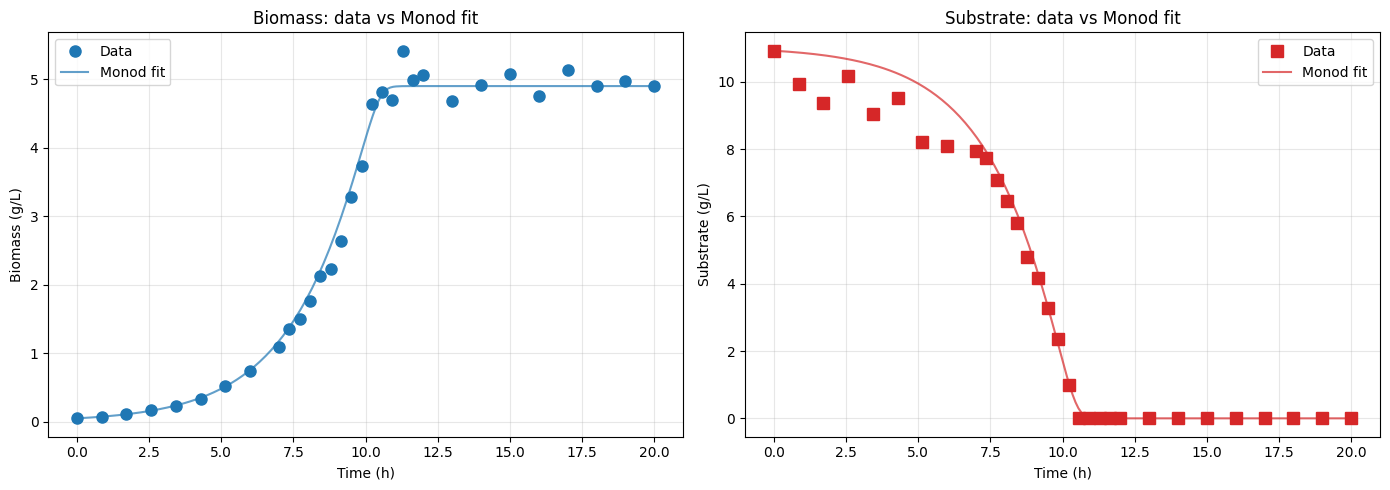

In [3]:
# Forward-simulate with the fitted parameters at a fine time grid for smooth curves
t_smooth = np.linspace(t_data.min(), t_data.max(), 200)
X_smooth, S_smooth = simulate_monod(result.x, t_smooth, X0, S0)

# Also get predictions at the data time points for residuals
X_pred_at_data, S_pred_at_data = simulate_monod(result.x, t_data, X0, S0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: biomass
ax1.plot(t_data, X_data, 'o', color='C0', label='Data', markersize=8)
ax1.plot(t_smooth, X_smooth, '-', color='C0', label='Monod fit', alpha=0.7)
ax1.set_xlabel('Time (h)')
ax1.set_ylabel('Biomass (g/L)')
ax1.set_title('Biomass: data vs Monod fit')
ax1.legend()
ax1.grid(alpha=0.3)

# Right panel: substrate
ax2.plot(t_data, S_data, 's', color='C3', label='Data', markersize=8)
ax2.plot(t_smooth, S_smooth, '-', color='C3', label='Monod fit', alpha=0.7)
ax2.set_xlabel('Time (h)')
ax2.set_ylabel('Substrate (g/L)')
ax2.set_title('Substrate: data vs Monod fit')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/03_monod_fit.png')
plt.show()

In [9]:
# Compute R² for biomass and substrate
def r_squared(y_data, y_pred):
    ss_res = np.sum((y_data - y_pred) ** 2)
    ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
    return 1 - ss_res / ss_tot

r2_X = r_squared(X_data, X_pred_at_data)
r2_S = r_squared(S_data, S_pred_at_data)

print(f"R² for biomass:   {r2_X:.4f}")
print(f"R² for substrate: {r2_S:.4f}")
print(f"\nResidual norm: {np.linalg.norm(residuals_monod(result.x, t_data, X_data, S_data, X0, S0)):.4f}")

R² for biomass:   0.9928
R² for substrate: 0.9786

Residual norm: 0.3490


Both R² values should be above 0.95 for a clean fit on noisy synthetic data. If they're closer to 0.85, your fit is OK but not great — usually means initial guesses or bounds need adjusting.⬆️⬆️⬆️

In [4]:
import pandas as pd
df_check = pd.read_csv('../data/synthetic_batch_fermentation.csv')
print(f"Number of data points: {len(df_check)}")
print(f"Time points: {df_check['time_h'].values}")

Number of data points: 31
Time points: [ 0.          0.85714286  1.71428571  2.57142857  3.42857143  4.28571429
  5.14285714  6.          7.          7.35714286  7.71428571  8.07142857
  8.42857143  8.78571429  9.14285714  9.5         9.85714286 10.21428571
 10.57142857 10.92857143 11.28571429 11.64285714 12.         13.
 14.         15.         16.         17.         18.         19.
 20.        ]
